# 1. Load the dataset, airfoil_self_noise.dat, into memory. (Hint: This file is tab separated file.)

In [1]:
from google.colab import files
uploaded = files.upload()

Saving airfoil_self_noise.dat to airfoil_self_noise (2).dat


In [2]:
import pandas as pd

columns = [
    "Frequency",
    "Attack_Angle",
    "Chord_length",
    "Free_stream_velocity",
    "Suction_side_displacement_thickness",
    "Scaled_sound_pressure_level"
]

# Load the tab-separated dataset
df = pd.read_csv("airfoil_self_noise.dat", sep="\t", header=None, names=columns)

# Display first few rows
df.head()

,Frequency,Attack_Angle,Chord_length,Free_stream_velocity,Suction_side_displacement_thickness,Scaled_sound_pressure_level
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


2. Clean the data and check missing values for this dataset.

In [3]:
df.dtypes

,0
Frequency,int64
Attack_Angle,float64
Chord_length,float64
Free_stream_velocity,float64
Suction_side_displacement_thickness,float64
Scaled_sound_pressure_level,float64


In [4]:
df.isnull().sum(axis=0)

,0
Frequency,0
Attack_Angle,0
Chord_length,0
Free_stream_velocity,0
Suction_side_displacement_thickness,0
Scaled_sound_pressure_level,0


In [5]:
df.describe()

,Frequency,Attack_Angle,Chord_length,Free_stream_velocity,Suction_side_displacement_thickness,Scaled_sound_pressure_level
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,2886.380572,6.782302,0.136548,50.860745,0.011140,124.835943
std,3152.573137,5.918128,0.093541,15.572784,0.013150,6.898657
min,200.000000,0.000000,0.025400,31.700000,0.000401,103.380000
25%,800.000000,2.000000,0.050800,39.600000,0.002535,120.191000
50%,1600.000000,5.400000,0.101600,39.600000,0.004957,125.721000
75%,4000.000000,9.900000,0.228600,71.300000,0.015576,129.995500
max,20000.000000,22.200000,0.304800,71.300000,0.058411,140.987000


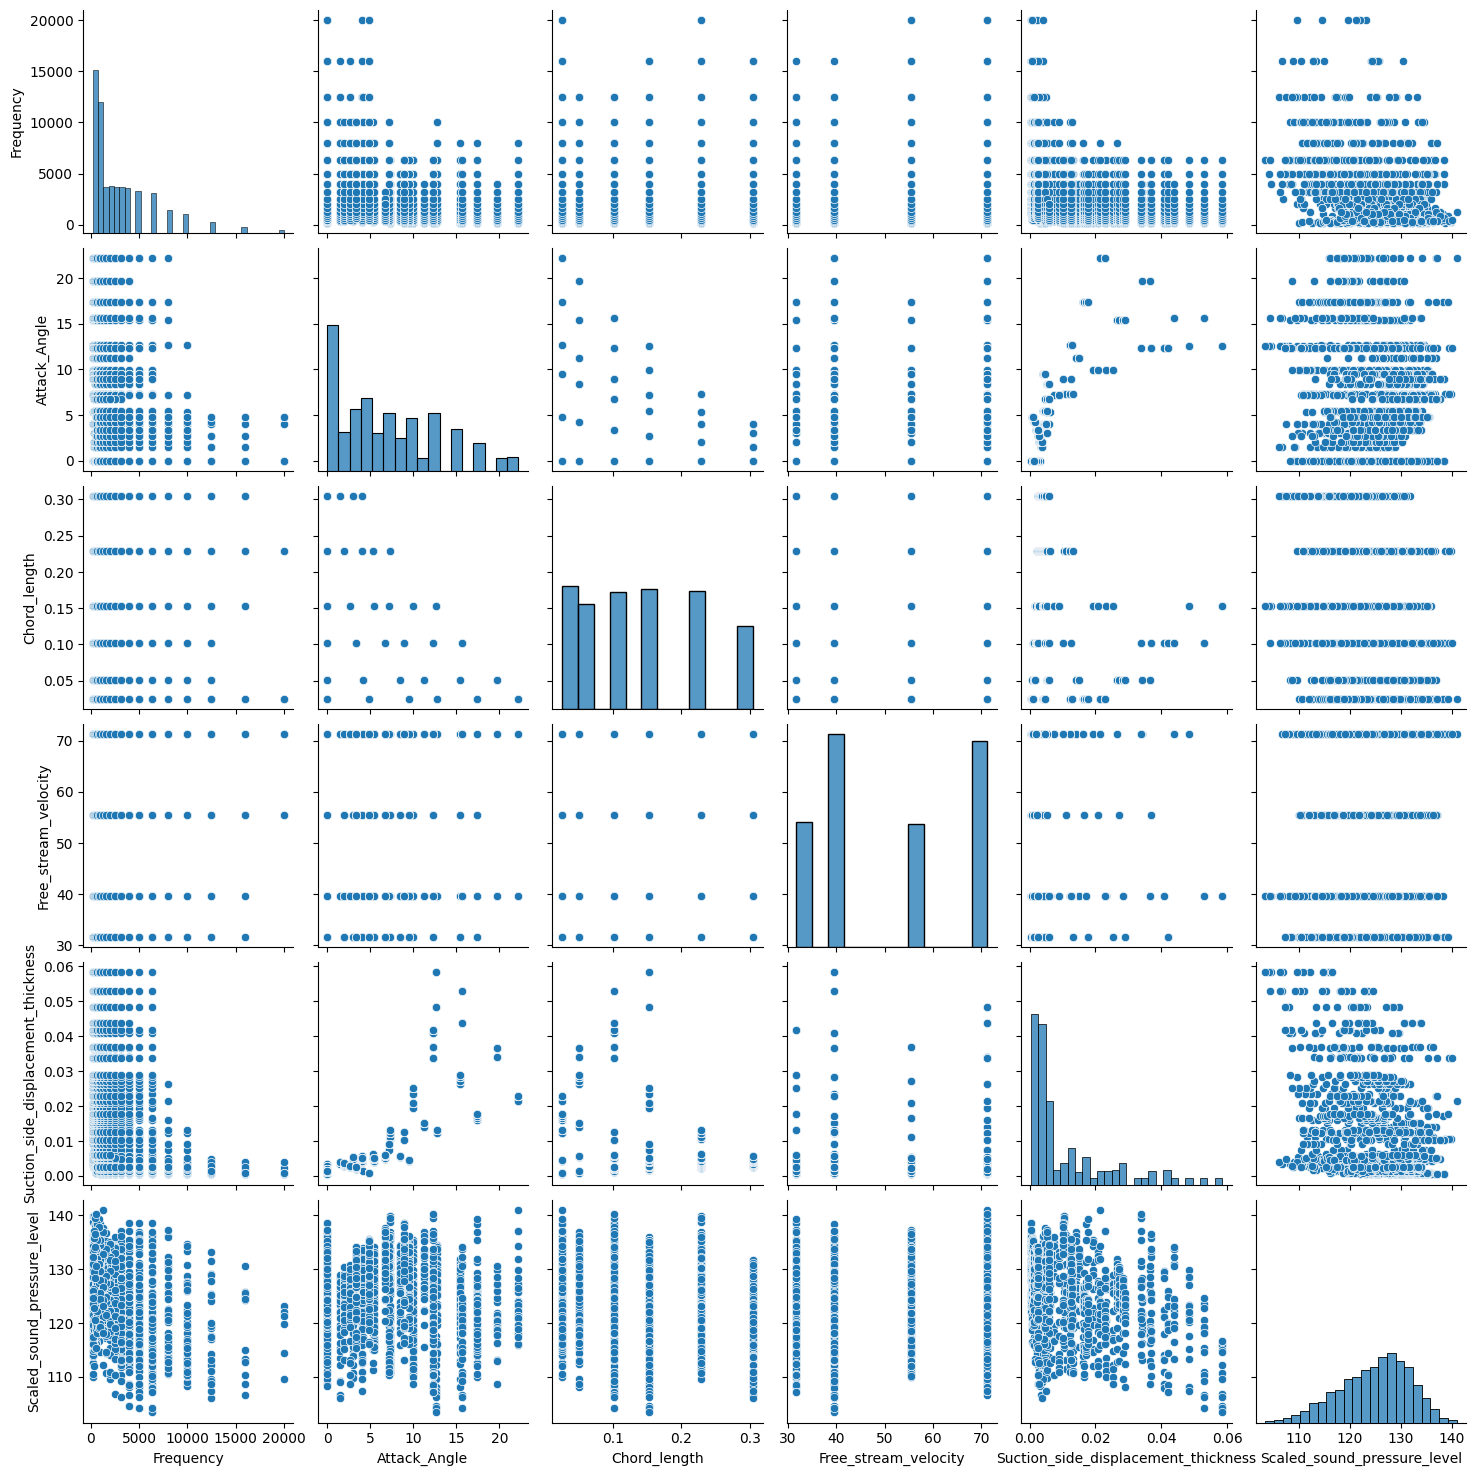

In [6]:
import seaborn as sns
sns.pairplot(df)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.shape

(1503, 6)

3. Split the data into 80% of training and 20% of the test dataset. Build a simple linear regression to forecast "Scaled sound pressure level" using all other features and scikit-learn package. What's the test error for this scikit-learn regression model?

In [9]:
#obtain features and label
X = df.drop("Scaled_sound_pressure_level", axis=1)
y = df["Scaled_sound_pressure_level"]

#split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 2026)

In [10]:
#Train Linear Regression Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [11]:
#Make Predictions
y_pred = model.predict(X_test)

In [12]:
#Calculate Test Error (MSE)
from sklearn.metrics import mean_squared_error

test_error = mean_squared_error(y_test, y_pred)
print(test_error)

24.783257788348678


What's the test error for this scikit-learn regression model? : **24.783257788348678**

4. Preprocess the data using the normalization method to convert all features into the range of [0,1].




In [13]:
#Data Normalization

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
#Fit and transform the training data
X_train= scaler.fit_transform(X_train)
#Transform the test data
X_test = scaler.transform(X_test)

5. Build a deep learning regression model to forecast "Scaled sound pressure level" using all other features and TensorFlow. Please use only two layers of the neuron network. You choose the number of neurons to use in the first layer. What's the test error for this model?

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [15]:
model = keras.Sequential(
    [
        # first layer has 16 neurons
        layers.Dense(16, activation='relu'),
        #last layer has one and only one neuron
        layers.Dense(1),
    ]
)

In [16]:
#Compile the Model
model.compile(optimizer='adam',loss='mse')

In [17]:
#train the model
tf.random.set_seed(1)
model.fit(x=X_train,y=y_train,batch_size=64,epochs=100,
          validation_data=(X_test,y_test)
          )

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 15526.6738 - val_loss: 15599.6025
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15484.1035 - val_loss: 15555.3418
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15436.4707 - val_loss: 15504.9717
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15381.2314 - val_loss: 15445.7422
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15315.2080 - val_loss: 15373.5762
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15235.5742 - val_loss: 15288.4307
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15142.2031 - val_loss: 15190.0586
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15034.7451 - val_loss: 15078.1025
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14914.2959 - val_loss: 14955.0879
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14783.4639 - val_loss: 14822.8320
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14643.32

In [18]:
X_train.shape

(1202, 5)

In [19]:
#Evaluate the Model on the Test Data
from sklearn.metrics import mean_squared_error,mean_absolute_error
y_pred = model.predict(X_test)
'The mean square error is {0:.4f}'.format(mean_squared_error(y_test,y_pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


'The mean square error is 1155.9168'

What's the test error for this model? : **1155.9168**

Can you improve the model performance of question 5 by adjusting the number of neurons or the optimization algorithm?

**Yes, we can improve the performance by adjusting the number of neurons or the optimization algorithm.**

In [20]:
model2 = keras.Sequential(
    [
        # first layer has 16 neurons
        layers.Dense(32, activation='relu'),
        #last layer has one and only one neuron
        layers.Dense(1),
    ]
)
model2.compile(optimizer='adam',loss='mse')
tf.random.set_seed(1)
model2.fit(x=X_train,y=y_train,batch_size=32,epochs=150,
          validation_data=(X_test,y_test)
          )
from sklearn.metrics import mean_squared_error,mean_absolute_error
y_pred = model2.predict(X_test)
'The mean square error is {0:.4f}'.format(mean_squared_error(y_test,y_pred))

Epoch 1/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 15569.8584 - val_loss: 15601.9648
Epoch 2/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15440.1895 - val_loss: 15454.2510
Epoch 3/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15254.3496 - val_loss: 15235.7275
Epoch 4/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14989.8271 - val_loss: 14937.3389
Epoch 5/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14645.8799 - val_loss: 14568.1943
Epoch 6/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14236.0400 - val_loss: 14140.5498
Epoch 7/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13769.3691 - val_loss: 13660.5918
Epoch 8/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13251.9619 - val_loss: 13133.9746
Epoch 9/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12689.9307 - val_loss: 12566.8193
Epoch 10/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12089.9053 - val_loss: 11965.7109
Epoch 11/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11458.900

'The mean square error is 54.6672'

Improved performance : mean square error is **54.6672**

Build a deep learning regression model to forecast "Scaled sound pressure level" using all other features and PyTorch. Please use only two layers of the neuron network. You choose the number of neurons to use in the first layer. What's the test error for this model?

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

In [22]:
#PyTorch
X_train = torch.tensor(X_train.astype(np.float32))
y_train = torch.tensor(y_train.values.astype(np.float32).reshape(-1,1))

In [23]:
y_train.shape

torch.Size([1202, 1])

In [24]:
input_size = X_train.shape[1]
output_size = y_train.shape[1]
#specify the number of neuron for the first layer
hidden_size = 10
print(input_size)
print(output_size)

5
1


In [25]:
# define the child module class derivated from parent class of torch.nn.Module)
class LinearRegressionModel(torch.nn.Module):
    #define the constructor
    def __init__(self, input_size, hidden_size, output_size):
        super(LinearRegressionModel, self).__init__()
        self.hidden = torch.nn.Linear(input_size, hidden_size)
        self.predict = torch.nn.Linear(hidden_size, output_size)
    #overife the forward function in this child class
    def forward(self, x):
        x = F.relu(self.hidden(x))
        y_pred = self.predict(x)
        return y_pred

In [26]:
model = LinearRegressionModel(input_size, hidden_size, output_size)

In [27]:
#Define Loss and Optimizer
l = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

In [28]:
#Train the Model

#fix the random seeds for troch and np
torch.manual_seed(1)
np.random.seed(0)

#set the number of epochs
num_epochs = 100
for epoch in range(num_epochs):
    #forward pass
    y_pred = model(X_train.requires_grad_())

    #calculate the loss
    loss= l(y_pred, y_train)
    #Set the gradients to be zero
    optimizer.zero_grad()

    #backward pass: calculate gradients
    loss.backward()

    #update the weights
    optimizer.step()

    print('epoch {0}, loss:{1:.4f}'.format(epoch, loss.item()))

epoch 0, loss:15500.6875
epoch 1, loss:15422.8848
epoch 2, loss:15340.4824
epoch 3, loss:15248.9082
epoch 4, loss:15146.2061
epoch 5, loss:15030.6934
epoch 6, loss:14901.0752
epoch 7, loss:14756.4375
epoch 8, loss:14596.2314
epoch 9, loss:14419.9971
epoch 10, loss:14227.6172
epoch 11, loss:14018.9854
epoch 12, loss:13794.0371
epoch 13, loss:13552.6865
epoch 14, loss:13294.9111
epoch 15, loss:13020.7715
epoch 16, loss:12730.3984
epoch 17, loss:12424.0137
epoch 18, loss:12101.9141
epoch 19, loss:11764.4951
epoch 20, loss:11412.2500
epoch 21, loss:11045.7500
epoch 22, loss:10665.6777
epoch 23, loss:10272.7441
epoch 24, loss:9867.7588
epoch 25, loss:9451.5029
epoch 26, loss:9025.0820
epoch 27, loss:8589.6338
epoch 28, loss:8146.5107
epoch 29, loss:7696.6738
epoch 30, loss:7241.8467
epoch 31, loss:6784.6978
epoch 32, loss:6327.4189
epoch 33, loss:5872.3613
epoch 34, loss:5422.0781
epoch 35, loss:4979.2827
epoch 36, loss:4546.8169
epoch 37, loss:4127.6055
epoch 38, loss:3724.6123
epoch 39, l

In [29]:
#Evaluate the Model on the Test Data (PyTorch)

#convert numpy to tensor
X_test = torch.from_numpy(X_test.astype(np.float32))
#Stop tracking the gradient by calling detach since we don't use it anymore
y_pred = model(X_test).detach().numpy()

In [30]:
from sklearn.metrics import mean_squared_error
'The mean square error is {0:.4f}'.format(mean_squared_error(y_test,y_pred))

'The mean square error is 804.7899'

What's the test error for this model? : **804.7899**

Can you improve the model performance of question 7 by adjusting the number of neurons or the optimization algorithm?

**Yes, we can.**

In [31]:
input_size = X_train.shape[1]
output_size = y_train.shape[1]
#specify the number of neuron for the first layer
hidden_size = 32
print(input_size)
print(output_size)
class LinearRegressionModel(torch.nn.Module):
    #define the constructor
    def __init__(self, input_size, hidden_size, output_size):
        super(LinearRegressionModel, self).__init__()
        self.hidden = torch.nn.Linear(input_size, hidden_size)
        self.predict = torch.nn.Linear(hidden_size, output_size)
    #overife the forward function in this child class
    def forward(self, x):
        x = F.relu(self.hidden(x))
        y_pred = self.predict(x)
        return y_pred
model = LinearRegressionModel(input_size, hidden_size, output_size)

#Define Loss and Optimizer
l = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

#Train the Model

#fix the random seeds for troch and np
torch.manual_seed(1)
np.random.seed(0)

#set the number of epochs
num_epochs = 300
for epoch in range(num_epochs):
    #forward pass
    y_pred = model(X_train.requires_grad_())

    #calculate the loss
    loss= l(y_pred, y_train)
    #Set the gradients to be zero
    optimizer.zero_grad()

    #backward pass: calculate gradients
    loss.backward()

    #update the weights
    optimizer.step()

    print('epoch {0}, loss:{1:.4f}'.format(epoch, loss.item()))

    #Evaluate the Model on the Test Data (PyTorch)


X_test = X_test.float()
#Stop tracking the gradient by calling detach since we don't use it anymore
y_pred = model(X_test).detach().numpy()

from sklearn.metrics import mean_squared_error
'The mean square error is {0:.4f}'.format(mean_squared_error(y_test,y_pred))

5
1
epoch 0, loss:15602.0029
epoch 1, loss:15578.3965
epoch 2, loss:15554.2861
epoch 3, loss:15529.4424
epoch 4, loss:15503.6104
epoch 5, loss:15476.4941
epoch 6, loss:15447.8848
epoch 7, loss:15417.5342
epoch 8, loss:15385.1982
epoch 9, loss:15350.6924
epoch 10, loss:15313.8008
epoch 11, loss:15274.3926
epoch 12, loss:15232.3193
epoch 13, loss:15187.4941
epoch 14, loss:15139.7373
epoch 15, loss:15088.9717
epoch 16, loss:15035.0713
epoch 17, loss:14977.9648
epoch 18, loss:14917.5273
epoch 19, loss:14853.7041
epoch 20, loss:14786.3926
epoch 21, loss:14715.5254
epoch 22, loss:14641.0645
epoch 23, loss:14562.9219
epoch 24, loss:14481.0117
epoch 25, loss:14395.2441
epoch 26, loss:14305.6572
epoch 27, loss:14212.1533
epoch 28, loss:14114.7002
epoch 29, loss:14013.2959
epoch 30, loss:13907.9307
epoch 31, loss:13798.5752
epoch 32, loss:13685.2148
epoch 33, loss:13567.8418
epoch 34, loss:13446.4463
epoch 35, loss:13321.0312
epoch 36, loss:13191.6035
epoch 37, loss:13058.1777
epoch 38, loss:129

'The mean square error is 591.2424'

New improved mean square error: **591.2424**